# Malaria Prediction — Final Deployment Artifacts
## Train & Save 4 Models (lag / no-lag × regression / classification)
*Cameroon health districts · MAPE16_H_13 · for the operations phase*

---

### Purpose
Produce the production model bundle for the operations notebook. Four models are
trained on **all available data (2019–2022)** and saved, together with the
artifacts needed to score new climate data.

### The two-model deployment chain
At inference each month arrives with **climate data only** (no real cases):

```
Month t (climate only, no cases)
   │
   ├─ Bootstrap → NO-LAG regressor predicts cases_t  (needs no case history)
   │
   └─ Month t+1 onward → predicted cases_t becomes cases_lag1
                         LAG regressor predicts recursively (synthetic lags)
```

- **NO-LAG models** start the chain (climate + geography + season only).
- **LAG models** continue it, consuming the model's own previous predictions
  when real case data is unavailable (recursive forecasting).

### Saved bundle
| File | Role |
|---|---|
| `regressor_nolag.joblib` | Bootstrap: predict log_cases from climate |
| `classifier_nolag.joblib` | Risk class from climate |
| `regressor_lag.joblib` | Recursive: predict log_cases using lags |
| `classifier_lag.joblib` | Risk class using lags |
| `district_static.csv` | lat/lon/area/cluster/population/threshold per district |
| `artifacts.json` | feature lists, thresholds, scores, fuzzy map |

Both regressors predict **`log_cases`** so the recursive loop can feed cases back
as `cases_lag`. Incidence and risk class are then derived from predicted cases ÷
population vs the per-region 75th-percentile threshold.


## 0 · Setup

In [1]:
import warnings, numpy as np, pandas as pd, json, os, joblib, copy
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore')
from rapidfuzz import process, fuzz
from sklearn.model_selection import KFold, TimeSeriesSplit, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, r2_score, mean_absolute_error
import xgboost as xgb
SEED=42; np.random.seed(SEED)
sns.set_style('whitegrid'); plt.rcParams.update({'figure.dpi':120,'savefig.dpi':150})
print('Setup OK')


Setup OK


## 1 · Data Pipeline

In [2]:
PNLP_FILE='PNLP_AS_COMPLETE_WITH_FILL_NA_ok_5.csv'; CLIMATE_FILE='cameroon_districts_climate.csv'
df_raw=pd.read_csv(PNLP_FILE,sep=';')
for col in ['SHP_lat','SHP_lon','SHP_Area']:
    df_raw[col]=pd.to_numeric(df_raw[col].astype(str).str.replace(',','.'),errors='coerce')
climate_raw=pd.read_csv(CLIMATE_FILE,parse_dates=['Date'])
MONTH_MAP={'Jan':'01','Fev':'02','Mar':'03','Avr':'04','Mai':'05','Jun':'06','Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
def c2d(col):
    p=col.split('_'); return pd.Timestamp(f"{p[1]}-{MONTH_MAP[p[0]]}-01") if len(p)>=2 and p[0] in MONTH_MAP else None
mape=[c for c in df_raw.columns if 'MAPE16_H_13' in c]
dist_static=df_raw.groupby(['district','region']).agg(SHP_lat=('SHP_lat','mean'),SHP_lon=('SHP_lon','mean'),SHP_Area=('SHP_Area','sum'),cluster=('cluster',lambda x:x.mode()[0]),p_totale=('p_totale','sum')).reset_index()
dmp=df_raw.groupby(['district','region'])[mape].sum().reset_index()
df_m=dmp.melt(id_vars=['district','region'],value_vars=mape,var_name='rc',value_name='cases')
df_m['date']=df_m['rc'].map(c2d); df_m=df_m.dropna(subset=['date']).drop(columns='rc').sort_values(['district','date']).reset_index(drop=True)
df_m=df_m.merge(dist_static,on=['district','region']); df_m['incidence_rate']=(df_m['cases']/df_m['p_totale'])*1000
cm=(climate_raw.groupby(['Location',pd.Grouper(key='Date',freq='MS')]).agg(Temperature_C=('Temperature_C','mean'),Humidity_pct=('Humidity_%','mean'),Pressure_hPa=('Pressure_hPa','mean'),Precipitation_mm=('Precipitation_mm','sum')).reset_index().rename(columns={'Date':'date','Location':'location'}))
cl=climate_raw['Location'].unique().tolist()
FUZZY_MAP={'Garoua II':'Garoua I','Mbanga':'Mbang','Kumba-North':'Kumba-South','Maroua 2':'Maroua 1','Maroua 3':'Maroua 1','Ngaoundere Urbain':'Ngaoundere Rural','Maga':'Mada','Batcham':'Baham','Manoka':'Manjo','Ndom':'Ndop'}
def gl(d):
    if d in set(cl): return d
    if d in FUZZY_MAP: return FUZZY_MAP[d]
    b=process.extractOne(d,cl,scorer=fuzz.token_sort_ratio); return b[0] if b and b[1]>=55 else None
df_m['climate_loc']=df_m['district'].map(gl)
df=df_m.merge(cm,left_on=['climate_loc','date'],right_on=['location','date'],how='left').drop(columns='location')
for col in ['Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm']:
    df[col]=df[col].fillna(df.groupby(['region','date'])[col].transform('mean')); df[col]=df[col].fillna(df[col].mean())
df['month']=df['date'].dt.month; df['sin_month']=np.sin(2*np.pi*df['month']/12); df['cos_month']=np.cos(2*np.pi*df['month']/12)
df=df.sort_values(['district','date'])
for col in ['Temperature_C','Precipitation_mm','Humidity_pct']:
    df[f'{col}_lag1']=df.groupby('district')[col].shift(1); df[f'{col}_lag2']=df.groupby('district')[col].shift(2)
for lag in [1,2,3]: df[f'cases_lag{lag}']=df.groupby('district')['cases'].shift(lag)
df['rolling_mean_3m']=df.groupby('district')['cases'].transform(lambda x:x.shift(1).rolling(3,min_periods=1).mean())
df['log_cases']=np.log1p(df['cases'])
r75=df.groupby('region')['incidence_rate'].quantile(0.75).rename('threshold_75'); df=df.merge(r75,on='region')
df['high']=(df['incidence_rate']>df['threshold_75']).astype(int)

FEAT_NOLAG=['sin_month','cos_month','SHP_lat','SHP_lon','SHP_Area','cluster','Temperature_C','Humidity_pct','Pressure_hPa','Precipitation_mm','Temperature_C_lag1','Temperature_C_lag2','Precipitation_mm_lag1','Precipitation_mm_lag2','Humidity_pct_lag1','Humidity_pct_lag2']
FEAT_LAG=FEAT_NOLAG+['cases_lag1','cases_lag2','cases_lag3','rolling_mean_3m']
dfm=df.dropna(subset=['cases_lag3','Temperature_C_lag2']).copy().sort_values('date').reset_index(drop=True)
spw=(dfm['high']==0).sum()/(dfm['high']==1).sum()
print(f'Rows {len(dfm)} | Districts {dfm.district.nunique()} | Months {dfm.date.nunique()}')
print(f'NO-LAG features: {len(FEAT_NOLAG)} | LAG features: {len(FEAT_LAG)}')


Rows 6895 | Districts 197 | Months 35
NO-LAG features: 16 | LAG features: 20


## 2 · Validation Scores (recorded for honest reporting)

We record both KFold (optimistic) and TimeSeriesSplit (honest, out-of-time)
scores for all four models. These go into `artifacts.json` so the operations
notebook and the thesis can quote defensible numbers.


In [3]:
def xreg(): return xgb.XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=SEED,verbosity=0)
def xclf(): return xgb.XGBClassifier(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,scale_pos_weight=spw,random_state=SEED,eval_metric='logloss',verbosity=0)

def score_reg(F):
    X=dfm[F].fillna(dfm[F].median()); y=dfm['log_cases']
    kf=[]; ts=[]
    for tr,te in KFold(5,shuffle=True,random_state=SEED).split(X):
        m=xreg(); m.fit(X.iloc[tr],y.iloc[tr]); kf.append(r2_score(y.iloc[te],m.predict(X.iloc[te])))
    for tr,te in TimeSeriesSplit(5).split(X):
        m=xreg(); m.fit(X.iloc[tr],y.iloc[tr]); ts.append(r2_score(y.iloc[te],m.predict(X.iloc[te])))
    return float(np.mean(kf)), float(np.mean(ts))
def score_clf(F):
    X=dfm[F].fillna(dfm[F].median()); y=dfm['high']
    kf=[]; ts=[]
    for tr,te in StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y):
        m=xclf(); m.fit(X.iloc[tr],y.iloc[tr]); kf.append(f1_score(y.iloc[te],m.predict(X.iloc[te]),zero_division=0))
    for tr,te in TimeSeriesSplit(5).split(X):
        if len(np.unique(y.iloc[tr]))<2 or len(np.unique(y.iloc[te]))<2: continue
        m=xclf(); m.fit(X.iloc[tr],y.iloc[tr]); ts.append(f1_score(y.iloc[te],m.predict(X.iloc[te]),zero_division=0))
    return float(np.mean(kf)), float(np.mean(ts))

reg_nolag_kf,reg_nolag_ts=score_reg(FEAT_NOLAG)
reg_lag_kf,reg_lag_ts=score_reg(FEAT_LAG)
clf_nolag_kf,clf_nolag_ts=score_clf(FEAT_NOLAG)
clf_lag_kf,clf_lag_ts=score_clf(FEAT_LAG)
scores=pd.DataFrame([
 ['Regressor NO-LAG','R² (log_cases)',reg_nolag_kf,reg_nolag_ts],
 ['Regressor LAG','R² (log_cases)',reg_lag_kf,reg_lag_ts],
 ['Classifier NO-LAG','F1',clf_nolag_kf,clf_nolag_ts],
 ['Classifier LAG','F1',clf_lag_kf,clf_lag_ts],
],columns=['Model','Metric','KFold','TimeSeriesSplit'])
display(scores.round(3))


,Model,Metric,KFold,TimeSeriesSplit
0,Regressor NO-LAG,R² (log_cases),0.898,0.839
1,Regressor LAG,R² (log_cases),0.941,0.915
2,Classifier NO-LAG,F1,0.742,0.668
3,Classifier LAG,F1,0.769,0.697


## 3 · Recursive Deployment Score (the realistic LAG number)

The LAG model's honest deployment performance is measured by feeding its own
predictions back as lags (no real case history), on the last 6 held-out months.


Oracle (real lags)        : R²=0.927  MAE=285 cases
Recursive (chain, synthetic): R²=0.875  MAE=321 cases


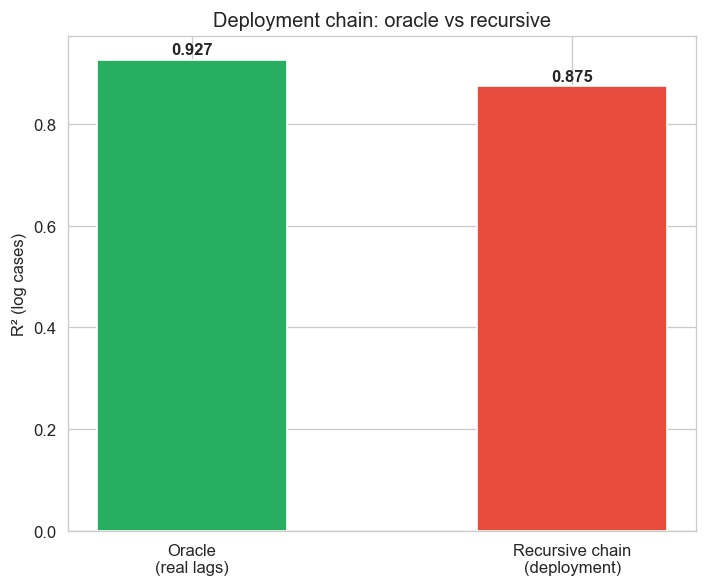

In [4]:
dates=sorted(dfm['date'].unique()); cut=dates[-6]; test_dates=dates[-6:]
train=dfm[dfm['date']<cut]
reg_lag_tmp=xreg(); reg_lag_tmp.fit(train[FEAT_LAG].fillna(train[FEAT_LAG].median()),train['log_cases'])
reg_nolag_tmp=xreg(); reg_nolag_tmp.fit(train[FEAT_NOLAG].fillna(train[FEAT_NOLAG].median()),train['log_cases'])
med=train[FEAT_LAG].median()
oracle=[]; recursive=[]
for dist in dfm['district'].unique():
    sub=dfm[dfm['district']==dist].sort_values('date').set_index('date')
    if not all(d in sub.index for d in test_dates): continue
    ph=sub[sub.index<cut]['cases'].tolist()
    for i,d in enumerate(test_dates):
        row=sub.loc[d]
        # oracle (real lags)
        Xo=pd.DataFrame([row[FEAT_LAG]]).fillna(med)[FEAT_LAG]; po=np.expm1(reg_lag_tmp.predict(Xo)[0]); oracle.append((row['cases'],po))
        # recursive chain: bootstrap first month with NO-LAG, then LAG on synthetic
        if i==0:
            Xb=pd.DataFrame([row[FEAT_NOLAG]]).fillna(med[FEAT_NOLAG] if set(FEAT_NOLAG)<=set(med.index) else 0)[FEAT_NOLAG]
            pr=np.expm1(reg_nolag_tmp.predict(Xb)[0])
        else:
            fr=row[FEAT_LAG].copy()
            fr['cases_lag1']=ph[-1]; fr['cases_lag2']=ph[-2] if len(ph)>=2 else med['cases_lag2']; fr['cases_lag3']=ph[-3] if len(ph)>=3 else med['cases_lag3']
            fr['rolling_mean_3m']=np.mean(ph[-3:])
            Xr=pd.DataFrame([fr]).fillna(med)[FEAT_LAG]; pr=np.expm1(reg_lag_tmp.predict(Xr)[0])
        recursive.append((row['cases'],pr)); ph.append(pr)
o=np.array(oracle); r=np.array(recursive)
rec_r2=r2_score(np.log1p(r[:,0]),np.log1p(r[:,1])); rec_mae=mean_absolute_error(r[:,0],r[:,1])
ora_r2=r2_score(np.log1p(o[:,0]),np.log1p(o[:,1])); ora_mae=mean_absolute_error(o[:,0],o[:,1])
print(f'Oracle (real lags)        : R²={ora_r2:.3f}  MAE={ora_mae:.0f} cases')
print(f'Recursive (chain, synthetic): R²={rec_r2:.3f}  MAE={rec_mae:.0f} cases')
fig,ax=plt.subplots(figsize=(6,5))
ax.bar(['Oracle\n(real lags)','Recursive chain\n(deployment)'],[ora_r2,rec_r2],color=['#27ae60','#e74c3c'],edgecolor='white',width=0.5)
for i,v in enumerate([ora_r2,rec_r2]): ax.text(i,v+0.01,f'{v:.3f}',ha='center',fontweight='bold')
ax.set_ylabel('R² (log cases)'); ax.set_title('Deployment chain: oracle vs recursive')
plt.tight_layout(); plt.savefig('deploy_recursive.png',bbox_inches='tight'); plt.show()


## 4 · Train Final Models on ALL Data & Save Bundle

In [5]:
os.makedirs('deployment_bundle',exist_ok=True)

# Train all four on ALL available data
Xnl=dfm[FEAT_NOLAG].fillna(dfm[FEAT_NOLAG].median())
Xl =dfm[FEAT_LAG].fillna(dfm[FEAT_LAG].median())

regressor_nolag=xreg();  regressor_nolag.fit(Xnl, dfm['log_cases'])
regressor_lag  =xreg();  regressor_lag.fit(Xl,  dfm['log_cases'])
classifier_nolag=xclf(); classifier_nolag.fit(Xnl, dfm['high'])
classifier_lag  =xclf(); classifier_lag.fit(Xl,  dfm['high'])

joblib.dump(regressor_nolag, 'deployment_bundle/regressor_nolag.joblib')
joblib.dump(regressor_lag,   'deployment_bundle/regressor_lag.joblib')
joblib.dump(classifier_nolag,'deployment_bundle/classifier_nolag.joblib')
joblib.dump(classifier_lag,  'deployment_bundle/classifier_lag.joblib')

district_static=(dfm[['district','region','SHP_lat','SHP_lon','SHP_Area','cluster','p_totale','threshold_75']]
                 .drop_duplicates('district').reset_index(drop=True))
district_static.to_csv('deployment_bundle/district_static.csv',index=False)

# Median feature values (for cold-start / missing lags at inference)
feat_medians=dfm[FEAT_LAG].median().to_dict()

artifacts={
 'feature_list_nolag':FEAT_NOLAG,
 'feature_list_lag':FEAT_LAG,
 'regression_target':'log_cases = log1p(MAPE16_H_13 monthly cases)',
 'classification_target':'high = incidence_rate > 75th pct per region',
 'incidence_formula':'incidence_rate = cases / p_totale * 1000',
 'scores':{
   'regressor_nolag':{'KFold_R2':reg_nolag_kf,'TimeSeriesSplit_R2':reg_nolag_ts},
   'regressor_lag':{'KFold_R2':reg_lag_kf,'TimeSeriesSplit_R2':reg_lag_ts,
                    'recursive_R2':float(rec_r2),'oracle_R2':float(ora_r2)},
   'classifier_nolag':{'KFold_F1':clf_nolag_kf,'TimeSeriesSplit_F1':clf_nolag_ts},
   'classifier_lag':{'KFold_F1':clf_lag_kf,'TimeSeriesSplit_F1':clf_lag_ts},
 },
 'feature_medians':feat_medians,
 'fuzzy_map':FUZZY_MAP,
 'climate_locations':cl,
 'deployment_notes':'Bootstrap with NO-LAG model (month 1, no case history), then '
                    'recursive LAG model feeding predicted cases back as cases_lag. '
                    'Report recursive_R2 as the realistic deployment figure.',
}
with open('deployment_bundle/artifacts.json','w') as f:
    json.dump(artifacts,f,indent=2,default=str)

print('Saved deployment_bundle/:')
for fn in sorted(os.listdir('deployment_bundle')): print('  ',fn)
print(f'\nDistrict static: {district_static.shape[0]} districts')
print(f'Scores recorded for all 4 models + recursive chain')


Saved deployment_bundle/:
   artifacts.json
   classifier_lag.joblib
   classifier_nolag.joblib
   district_static.csv
   regressor_lag.joblib
   regressor_nolag.joblib

District static: 197 districts
Scores recorded for all 4 models + recursive chain


## 5 · `predict()` Helper — copy this into the operations notebook

This function runs the full two-model chain for one district given a sequence of
monthly climate rows. It bootstraps month 1 with the NO-LAG model, then forecasts
recursively with the LAG model, deriving incidence and risk class each step.
Real case values, if available for a month, override the synthetic lag.


In [6]:
def predict_chain(climate_rows, static_row, models, feat_nolag, feat_lag,
                  feat_medians, real_cases=None):
    """
    climate_rows : list of dicts, each with the climate + season + lag-climate features for a month, in time order
    static_row   : dict with SHP_lat, SHP_lon, SHP_Area, cluster, p_totale, threshold_75
    models       : dict with keys 'reg_nolag','reg_lag','clf_nolag','clf_lag'
    real_cases   : optional list (same length); if a month's value is not None, it overrides the synthetic lag
    Returns a DataFrame with predicted cases, incidence, and risk class per month.
    """
    import pandas as pd, numpy as np
    out=[]; hist=[]   # case history (real where available, else predicted)
    pop=static_row['p_totale']; thr=static_row['threshold_75']
    for i,crow in enumerate(climate_rows):
        row={**crow, **{k:static_row[k] for k in ['SHP_lat','SHP_lon','SHP_Area','cluster']}}
        if i==0 or len(hist)<1:
            x=pd.DataFrame([row]).reindex(columns=feat_nolag).fillna(pd.Series(feat_medians))
            pc=float(np.expm1(models['reg_nolag'].predict(x)[0]))
            pcl=int(models['clf_nolag'].predict(x)[0]); src='NO-LAG'
        else:
            row['cases_lag1']=hist[-1]
            row['cases_lag2']=hist[-2] if len(hist)>=2 else feat_medians['cases_lag2']
            row['cases_lag3']=hist[-3] if len(hist)>=3 else feat_medians['cases_lag3']
            row['rolling_mean_3m']=float(np.mean(hist[-3:]))
            x=pd.DataFrame([row]).reindex(columns=feat_lag).fillna(pd.Series(feat_medians))
            pc=float(np.expm1(models['reg_lag'].predict(x)[0]))
            pcl=int(models['clf_lag'].predict(x)[0]); src='LAG'
        inc=pc/pop*1000
        out.append({'month_index':i+1,'pred_cases':round(pc),'pred_incidence':round(inc,2),
                    'risk_class':'High' if inc>thr else 'Low','model_used':src})
        # next lag uses real case if provided, else prediction
        use=pc
        if real_cases is not None and i<len(real_cases) and real_cases[i] is not None:
            use=real_cases[i]
        hist.append(use)
    return pd.DataFrame(out)

# ── Demo on one district from the held-out window ──
import joblib
M={'reg_nolag':regressor_nolag,'reg_lag':regressor_lag,'clf_nolag':classifier_nolag,'clf_lag':classifier_lag}
demo_dist='Mbalmayo'
sub=dfm[dfm['district']==demo_dist].sort_values('date').tail(6)
static_row=district_static[district_static['district']==demo_dist].iloc[0].to_dict()
climate_rows=[{k:row[k] for k in FEAT_LAG if k in row} for _,row in sub.iterrows()]
res=predict_chain(climate_rows, static_row, M, FEAT_NOLAG, FEAT_LAG, feat_medians)
res['actual_cases']=sub['cases'].values
display(res)
print(f"\nDemo: {demo_dist} — chain bootstraps with NO-LAG then recurses with LAG.")


,month_index,pred_cases,pred_incidence,risk_class,model_used,actual_cases
0,1,1309,10.04,Low,NO-LAG,1438
1,2,1242,9.53,Low,LAG,1522
2,3,1048,8.04,Low,LAG,1357
3,4,1134,8.70,Low,LAG,1756
4,5,1251,9.60,Low,LAG,1520
5,6,1100,8.43,Low,LAG,1424



Demo: Mbalmayo — chain bootstraps with NO-LAG then recurses with LAG.


---
## Summary

**Saved bundle (`deployment_bundle/`):**
- `regressor_nolag.joblib`, `classifier_nolag.joblib` — bootstrap (climate only)
- `regressor_lag.joblib`, `classifier_lag.joblib` — recursive (with lags)
- `district_static.csv` — per-district geography, population, threshold
- `artifacts.json` — feature lists, thresholds, all scores, medians, fuzzy map

**How operations uses it:**
1. Load the 4 models + `district_static.csv` + `artifacts.json`.
2. For each district, build monthly climate feature rows from sensor data.
3. Call `predict_chain()` — month 1 uses NO-LAG (no case history needed), then
   the LAG model takes over, feeding its own predictions back as `cases_lag`.
4. If real cases arrive for a month, pass them via `real_cases` to override the
   synthetic lag and re-anchor the chain.

**Honest numbers to report:** for the LAG model, quote `recursive_R2` (the chain
with synthetic lags), not the oracle. The NO-LAG model's TimeSeriesSplit score is
the deployable climate-only baseline.
